In [ ]:
!pip install -q opendatasets
import opendatasets as od


In [ ]:
od.download("https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: megavarshan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [01:00<00:00, 92.0MB/s]


In [ ]:
!ls /content
!ls /content/skin-cancer-mnist-ham10000


sample_data  skin-cancer-mnist-ham10000
ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv


In [ ]:
!mv /content/skin-cancer-mnist-ham10000/HAM10000_images_part_2/* /content/skin-cancer-mnist-ham10000/HAM10000_images_part_1/


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Load metadata
metadata_path = "/content/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"
metadata = pd.read_csv(metadata_path)

# Map labels
label_map = {name: idx for idx, name in enumerate(metadata['dx'].unique())}
metadata['label'] = metadata['dx'].map(label_map)

# Sample small dataset for fast training
train_df_full, val_df_full = train_test_split(metadata, stratify=metadata['label'], test_size=0.2, random_state=42)
train_df = train_df_full.sample(n=1000, random_state=42)
val_df = val_df_full.sample(n=300, random_state=42)


In [ ]:
image_dir = "/content/skin-cancer-mnist-ham10000/HAM10000_images_part_1"


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import torch.nn as nn
import torch.optim as optim

# Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Custom Dataset
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image_id'] + ".jpg"
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        label = self.df.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
# Datasets
train_dataset = SkinLesionDataset(train_df, image_dir, transform)
val_dataset = SkinLesionDataset(val_df, image_dir, transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# Load ConvNeXt-Tiny model
model = timm.create_model("convnext_tiny", pretrained=True, num_classes=7)
model.to(device)

# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


✅ Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [ ]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return total_loss / len(loader), accuracy


In [ ]:
epochs = 2

for epoch in range(epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"🔹 Train Loss: {train_loss:.4f}")
    print(f"🔹 Val Loss:   {val_loss:.4f}")
    print(f"🔹 Val Acc:    {val_acc*100:.2f}%\n")


Epoch 1/2
🔹 Train Loss: 1.1043
🔹 Val Loss:   1.0265
🔹 Val Acc:    67.33%

Epoch 2/2
🔹 Train Loss: 0.8751
🔹 Val Loss:   0.8493
🔹 Val Acc:    70.67%



In [ ]:
!pip install -q scikit-learn



📊 Classification Report:
              precision    recall  f1-score   support

         bkl       0.38      0.10      0.15        31
          nv       0.85      0.88      0.87       204
          df       0.00      0.00      0.00         3
         mel       0.38      0.59      0.46        32
        vasc       0.00      0.00      0.00         7
         bcc       0.33      0.62      0.43        16
       akiec       0.00      0.00      0.00         7

    accuracy                           0.71       300
   macro avg       0.28      0.31      0.27       300
weighted avg       0.67      0.71      0.68       300



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/IPython/c

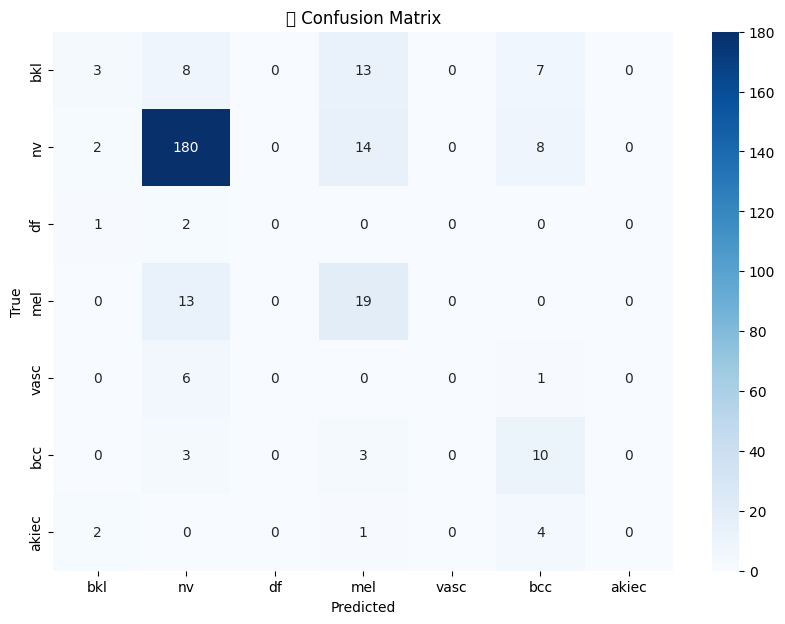

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Map label index back to label name
inv_label_map = {v: k for k, v in label_map.items()}

# Run prediction
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
target_names = [inv_label_map[i] for i in range(len(label_map))]
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("🧾 Confusion Matrix")
plt.show()


In [ ]:
torch.save(model.state_dict(), "convnext_skin_cancer.pth")
print("✅ Model saved as convnext_skin_cancer.pth")


✅ Model saved as convnext_skin_cancer.pth


In [ ]:
# Use full dataset (already stratified)
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(metadata, stratify=metadata['label'], test_size=0.2, random_state=42)
print("Train size:", len(train_df), " | Val size:", len(val_df))


Train size: 8012  | Val size: 2003


In [ ]:
from torchvision import transforms

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
train_dataset = SkinLesionDataset(train_df, image_dir, transform_train)
val_dataset = SkinLesionDataset(val_df, image_dir, transform_val)


In [ ]:
epochs = 10

for epoch in range(epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"🔹 Train Loss: {train_loss:.4f}")
    print(f"🔹 Val Loss:   {val_loss:.4f}")
    print(f"🔹 Val Acc:    {val_acc*100:.2f}%\n")


Epoch 1/10
🔹 Train Loss: 0.7537
🔹 Val Loss:   0.7867
🔹 Val Acc:    74.67%

Epoch 2/10
🔹 Train Loss: 0.6428
🔹 Val Loss:   0.6734
🔹 Val Acc:    73.00%

Epoch 3/10
🔹 Train Loss: 0.5223
🔹 Val Loss:   0.8191
🔹 Val Acc:    74.67%

Epoch 4/10
🔹 Train Loss: 0.4269
🔹 Val Loss:   0.9159
🔹 Val Acc:    68.67%

Epoch 5/10
🔹 Train Loss: 0.2994
🔹 Val Loss:   0.8235
🔹 Val Acc:    78.67%

Epoch 6/10
🔹 Train Loss: 0.2016
🔹 Val Loss:   1.1265
🔹 Val Acc:    69.00%

Epoch 7/10
🔹 Train Loss: 0.1374
🔹 Val Loss:   0.8998
🔹 Val Acc:    78.00%

Epoch 8/10
🔹 Train Loss: 0.0537
🔹 Val Loss:   1.1243
🔹 Val Acc:    75.00%

Epoch 9/10
🔹 Train Loss: 0.0219
🔹 Val Loss:   1.1138
🔹 Val Acc:    80.00%

Epoch 10/10
🔹 Train Loss: 0.0442
🔹 Val Loss:   1.2524
🔹 Val Acc:    75.33%



In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score


In [ ]:
# Binarize labels for ROC
y_true = []
y_scores = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).cpu()
        y_scores.append(outputs)
        y_true.extend(labels.cpu())

y_true = label_binarize(y_true, classes=list(range(len(label_map))))
y_scores = torch.cat(y_scores).numpy()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


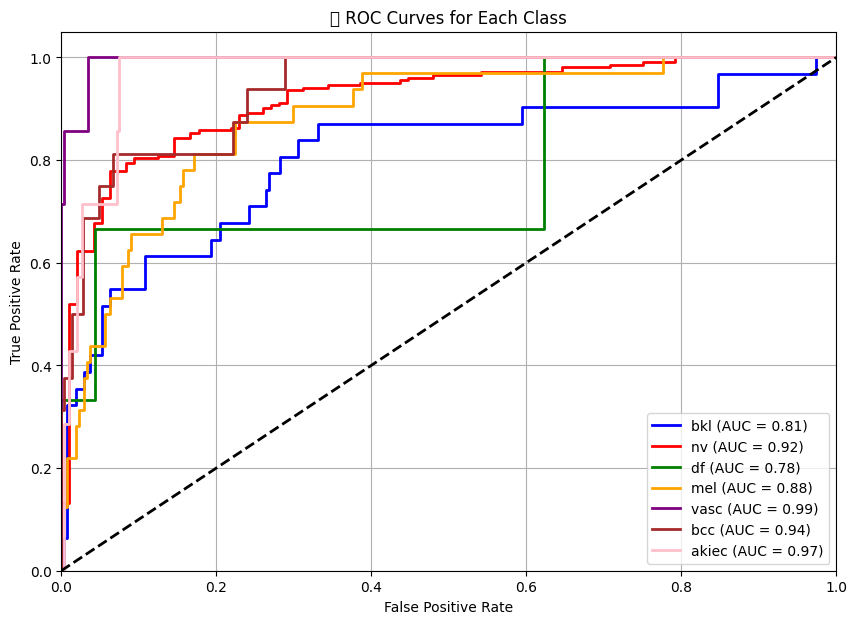

In [ ]:
from itertools import cycle

fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_true.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink'])
plt.figure(figsize=(10, 7))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{inv_label_map[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('📈 ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [ ]:
!pip install -q captum


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 44.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


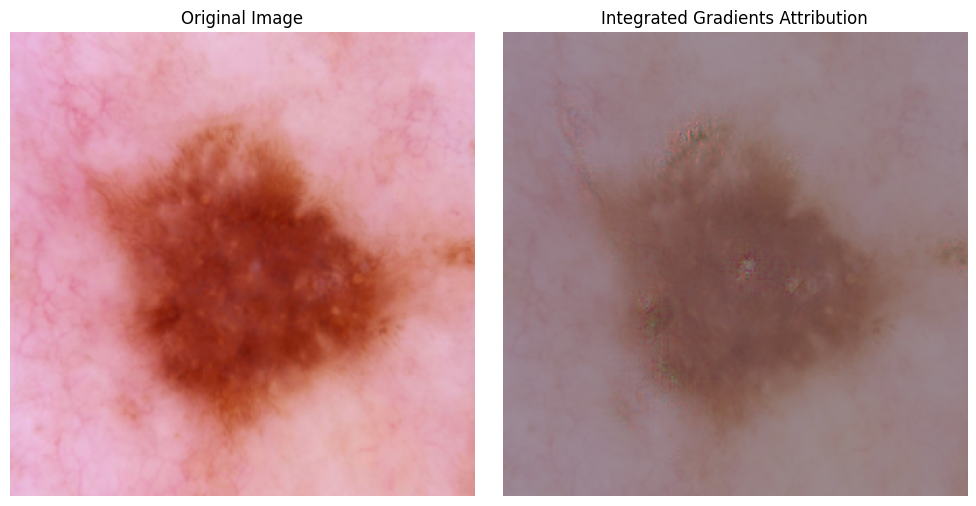

In [ ]:
from captum.attr import IntegratedGradients
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# STEP 1: Choose 1 image from validation set
sample_row = val_df.sample(n=1).iloc[0]
img_path = os.path.join(image_dir, sample_row['image_id'] + ".jpg")

# STEP 2: Load and preprocess image
img = Image.open(img_path).convert("RGB").resize((224, 224))
input_tensor = transform_val(img).unsqueeze(0).to(device)
input_tensor.requires_grad = True

# STEP 3: Convert original image to [0,1] numpy
original_image = np.array(img) / 255.0

# STEP 4: Run Integrated Gradients
ig = IntegratedGradients(model)

# ⚠️ Fix: Convert numpy.int64 to Python int
target = int(sample_row['label'])

attributions_ig = ig.attribute(input_tensor, target=target, n_steps=50)

# STEP 5: Visualize
attr = attributions_ig.squeeze().detach().cpu().numpy()
attr = np.transpose(attr, (1, 2, 0))
attr = (attr - attr.min()) / (attr.max() - attr.min())

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(original_image)
plt.imshow(attr, cmap='hot', alpha=0.6)
plt.title("Integrated Gradients Attribution")
plt.axis('off')
plt.tight_layout()
plt.show()


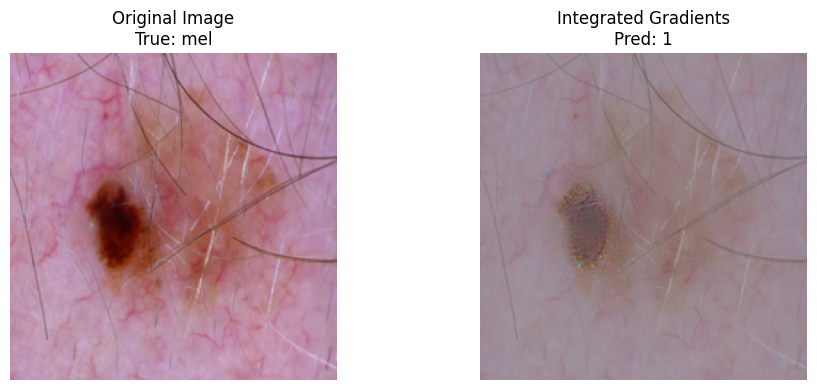

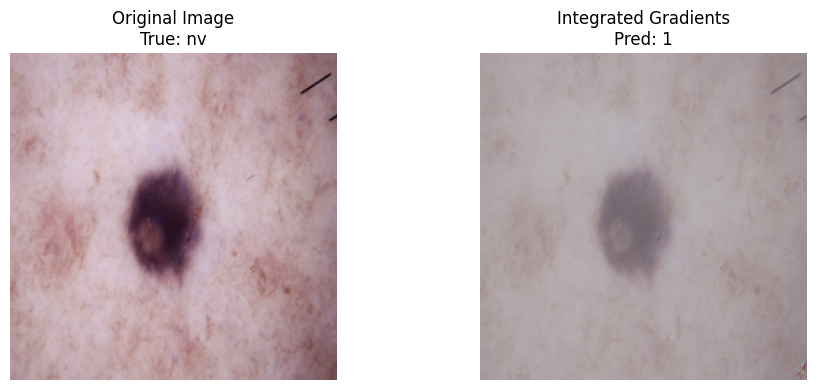

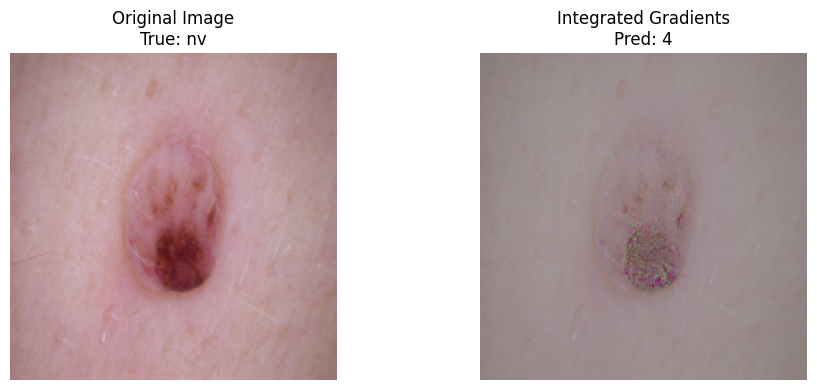

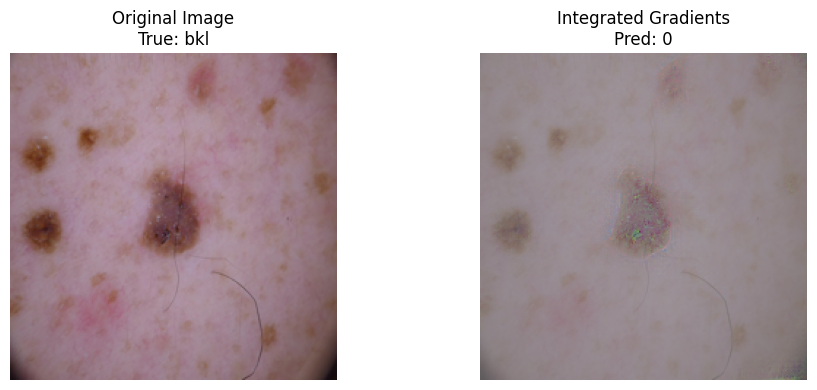

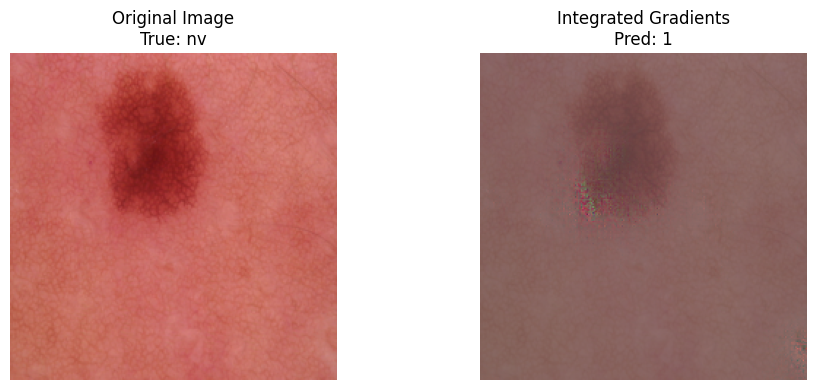

In [ ]:
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import os

# Initialize IG
ig = IntegratedGradients(model)

# Loop over 5 random images from validation set
samples = val_df.sample(n=5, random_state=42).reset_index(drop=True)

for i in range(5):
    row = samples.iloc[i]
    img_path = os.path.join(image_dir, row['image_id'] + ".jpg")

    # Load and preprocess image
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    input_tensor = transform_val(img).unsqueeze(0).to(device)
    input_tensor.requires_grad = True
    original_image = np.array(img) / 255.0

    # Target class (true label)
    target = int(row['label'])

    # Run IG
    attributions = ig.attribute(input_tensor, target=target, n_steps=50)
    attr = attributions.squeeze().detach().cpu().numpy()
    attr = np.transpose(attr, (1, 2, 0))
    attr = (attr - attr.min()) / (attr.max() - attr.min())

    # Get model prediction
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    # Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title(f"Original Image\nTrue: {row['dx']}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(original_image)
    plt.imshow(attr, cmap='hot', alpha=0.6)
    plt.title(f"Integrated Gradients\nPred: {pred_class}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
# Label-to-class mapping from metadata
label_mapping = {
    'nv': 0,        # Melanocytic nevi
    'mel': 1,       # Melanoma
    'bkl': 2,       # Benign keratosis-like lesions
    'bcc': 3,       # Basal cell carcinoma
    'akiec': 4,     # Actinic keratoses
    'vasc': 5,      # Vascular lesions
    'df': 6         # Dermatofibroma
}

# Reverse map for display
inv_label_mapping = {v: k for k, v in label_mapping.items()}


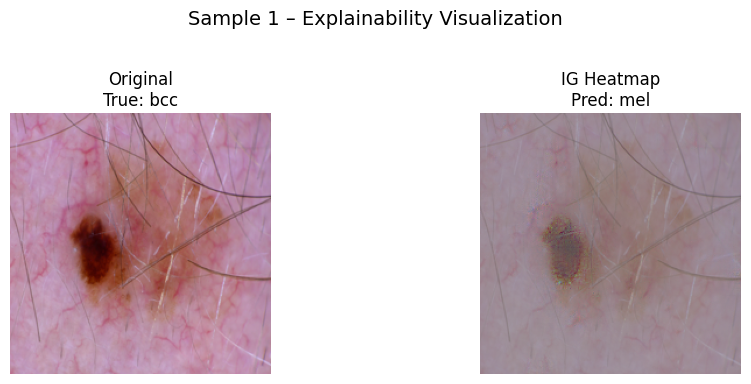

✅ Saved: /content/ig_visualizations/ig_sample_1.png


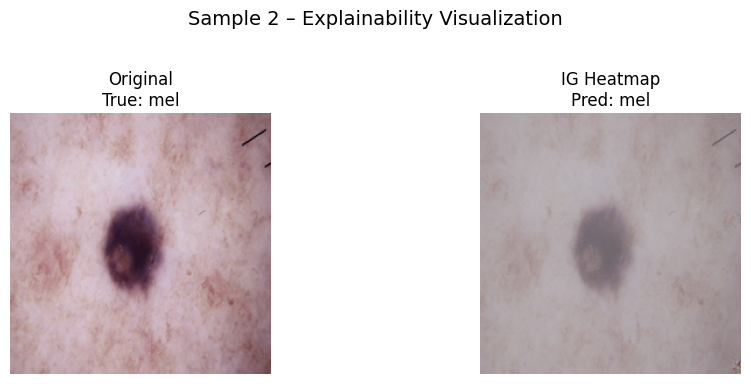

✅ Saved: /content/ig_visualizations/ig_sample_2.png


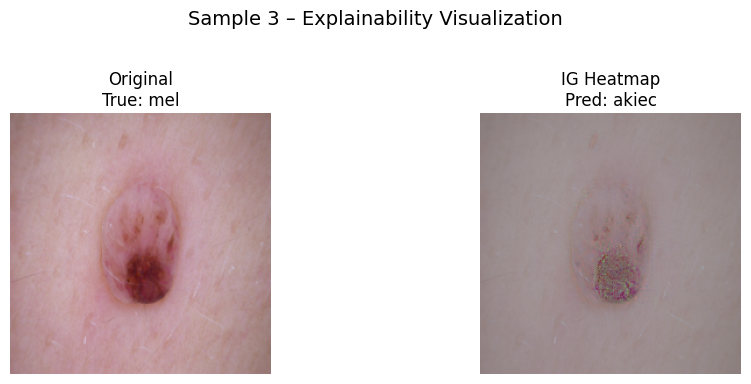

✅ Saved: /content/ig_visualizations/ig_sample_3.png


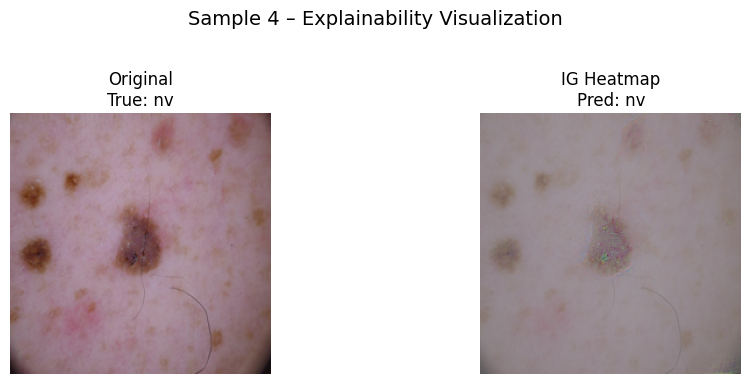

✅ Saved: /content/ig_visualizations/ig_sample_4.png


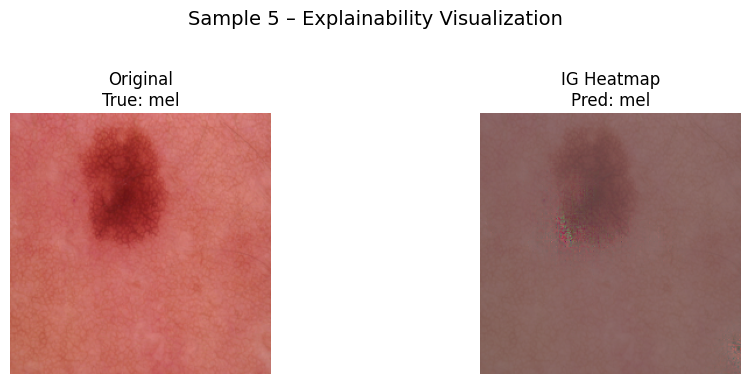

✅ Saved: /content/ig_visualizations/ig_sample_5.png


In [ ]:
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import os

ig = IntegratedGradients(model)

# Save directory
save_dir = "/content/ig_visualizations"
os.makedirs(save_dir, exist_ok=True)

# Sample 5 images
samples = val_df.sample(n=5, random_state=42).reset_index(drop=True)

for i in range(5):
    row = samples.iloc[i]
    img_path = os.path.join(image_dir, row['image_id'] + ".jpg")

    # Load and preprocess
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    input_tensor = transform_val(img).unsqueeze(0).to(device)
    input_tensor.requires_grad = True
    original_image = np.array(img) / 255.0

    # True label
    true_label_id = int(row['label'])
    true_label_name = inv_label_mapping[true_label_id]

    # Predict
    output = model(input_tensor)
    pred_label_id = torch.argmax(output, dim=1).item()
    pred_label_name = inv_label_mapping[pred_label_id]

    # IG
    attributions = ig.attribute(input_tensor, target=true_label_id, n_steps=50)
    attr = attributions.squeeze().detach().cpu().numpy()
    attr = np.transpose(attr, (1, 2, 0))
    attr = (attr - attr.min()) / (attr.max() - attr.min())

    # Plot
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title(f"Original\nTrue: {true_label_name}", fontsize=12)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(original_image)
    plt.imshow(attr, cmap='hot', alpha=0.6)
    plt.title(f"IG Heatmap\nPred: {pred_label_name}", fontsize=12)
    plt.axis('off')

    plt.suptitle(f"Sample {i+1} – Explainability Visualization", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save as PNG for report
    save_path = os.path.join(save_dir, f"ig_sample_{i+1}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"✅ Saved: {save_path}")


📊 Classification Report:

              precision    recall  f1-score   support

          nv       0.71      0.32      0.44        31
         mel       0.89      0.89      0.89       204
         bkl       1.00      0.33      0.50         3
         bcc       0.50      0.47      0.48        32
       akiec       0.83      0.71      0.77         7
        vasc       0.39      0.56      0.46        16
          df       0.23      0.71      0.34         7

    accuracy                           0.75       300
   macro avg       0.65      0.57      0.56       300
weighted avg       0.79      0.75      0.76       300



/tmp/ipython-input-40-1736126274.py:40: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 800x600 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


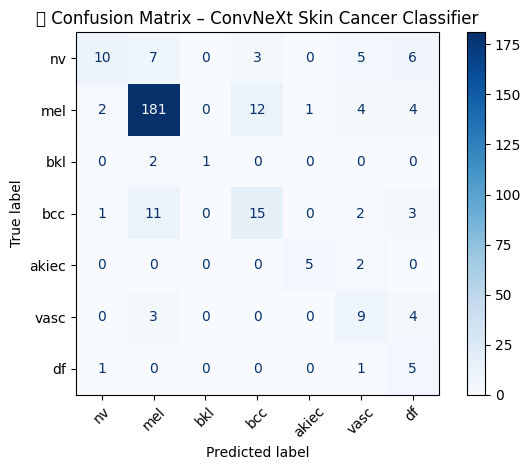

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import numpy as np

# Put model in evaluation mode
model.eval()

# Lists to store predictions and true labels
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Get class names from mapping
class_names = [inv_label_mapping[i] for i in range(len(inv_label_mapping))]

# Step 1: Classification report
print("📊 Classification Report:\n")
print(classification_report(all_targets, all_preds, target_names=class_names))

# Step 2: Confusion matrix
cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("📈 Confusion Matrix – ConvNeXt Skin Cancer Classifier")
plt.tight_layout()
plt.show()
